In [1]:
import pandas as pd
import ast
import numpy as np
import itertools

def softmax(x):
    return np.exp(x) / np.exp(x).sum()

def softmax_dim(x,axis):
    return np.exp(x) / np.sum(np.exp(x),axis=axis,keepdims=True)

numbers = [0,1,2,3]

def power_set(iterable):
    s = list(iterable)
    # Generate combinations for all possible lengths (i in range(len(s) + 1))
    return list(itertools.chain.from_iterable(itertools.combinations(s, i) for i in range(1,len(s) + 1)))

all_subsets = power_set(numbers)
print(all_subsets)

[(0,), (1,), (2,), (3,), (0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3), (0, 1, 2, 3)]


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
def plot_multiple(image_paths, image_labels=None,nrow=1,figsize=None):
    ncol = int(np.ceil(len(image_paths)/nrow))
    #print(ncol)
    if figsize is None:
        figsize=(ncol, nrow)
        
    fig, ax = plt.subplots(nrow,ncol, figsize=figsize)

    for id_image, image_path in enumerate(image_paths):
        if os.path.exists(image_path):
            img_now = cv2.cvtColor(cv2.imread(image_path),cv2.COLOR_BGR2RGB) 
        else:
            img_now = image_path

        if nrow>1:
            ax[id_image%nrow,id_image//nrow].imshow(img_now)
            ax[id_image%nrow,id_image//nrow].axis("off")
            if image_labels:
                ax[id_image%nrow,id_image//nrow].set_title(image_labels[id_image])
        else:
            ax[id_image].imshow(img_now)
            ax[id_image].axis("off")
            if image_labels:
                ax[id_image].set_title(image_labels[id_image])
    
    plt.tight_layout()
    return fig,ax

In [3]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

def compute_eer(y_true, y_score):
    """
    Compute Equal Error Rate (EER)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer,thresholds[eer_idx]


def evaluate_binary_classifier(y_true, y_pred, y_score):
    """
    y_true  : ground-truth labels (0 or 1)
    y_pred  : predicted labels (0 or 1)
    y_score : predicted probabilities or confidence scores for class 1
    """

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Metrics
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)

    avg_prec  = average_precision_score(y_true, y_score)
    roc_auc   = roc_auc_score(y_true, y_score)

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    eer,eer_thresh = compute_eer(y_true, y_score)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Average Precision": avg_prec,
        "FPR": fpr,
        "FNR": fnr,
        "ROC AUC": roc_auc,
        "EER": eer,
        "EER Threshold": eer_thresh
    }

In [4]:
def flagging_set(x):
    if '23Deepfake' in x: return 'DEEPFAKE'
    elif 'Danamon_20251119' in x: return 'REAL'
    elif 'Ganesha_20250916' in x:  return 'DEEPFAKE'
    elif 'Mobee_20250813' in x:  return 'REAL'
    elif 'Panin_20250925' in x:  return 'REAL'
    elif 'Panin_20250825'  in x:  return 'REAL'
    elif 'Danamon_20250718' in x:  return 'UNKNOWN'
    elif 'Experd_20250908' in x:  return 'REAL'
    elif 'Danamon_20251107' in x:  return 'REAL'
    elif 'Danamon_20251006' in x:  return 'REAL'
    elif 'Experd_20250811' in x:  return 'REAL'
    else:  return 'UNKNOWN'

In [5]:
import itertools

def generate_prob_vectors(classes, step=0.1):
    """
    Generate all probability vectors for given classes
    where values sum to 1.0 with a given step size.
    
    Args:
        classes (list): e.g. [0, 1, 2]
        step (float): resolution (default 0.1)
    
    Returns:
        list[list[float]]
    """
    n = len(classes)
    steps = int(1 / step)

    prob_vectors = []
    for comb in itertools.product(range(steps + 1), repeat=n):
        if sum(comb) == steps:
            prob_vectors.append([round(c * step, 1) for c in comb])

    return prob_vectors

In [6]:
df = pd.read_csv("test_multimodel_output_benchmark.txt", sep="|")

In [7]:
logits_columns = [i for i in list(df.columns) if 'logits_' in i]
dict_score = {}
for subs_now in all_subsets:
    logs_now = [logits_columns[i] for i in subs_now]
    models_now = ['_'.join(i.split('_')[1:]) for i in logs_now]
    scores_all = []
    for k in logs_now:
        scores_all.append(df[k].apply(eval))
    score_now = [softmax(i)[1] for i in np.sum(scores_all,axis=0)]
    dict_score['|'.join(models_now)]=score_now

In [8]:
dict_df = {}
dict_df["image_name"] = df["image_name"]
dict_df.update(dict_score)

In [9]:
df_result = pd.DataFrame(dict_df)

In [10]:
df_res = df.copy()
df_res["label_str"] =df_res["image_name"].apply(lambda x:flagging_set(x.split("/")[10]))
df_res["subgroup"]= df_res["image_name"].apply(lambda x:x.split("/")[10])
df_res["name"]= df_res["image_name"].apply(lambda x:x.split("/")[-1])
dict_label={
    "DEEPFAKE":1,
    "REAL":0,
    "UNKNOWN":-99
}
df_res["label"] = df_res["label_str"].apply(lambda x:dict_label.get(x))
df_res = df_res[df_res["label"].isin([0,1])]
df_res = df_res[df_res["image_name"].apply(lambda x:"experd" not in x.lower())]
df_res_raw = df_res.copy()

In [11]:
df_res2 = pd.read_csv("test_multimodel_json_combined_deepfake_data_rev_output.txt",sep='|')
df_res2["subgroup"]= df_res2["image_name"].apply(lambda x:x.split("/")[7])

In [12]:
df_res1 = df_res_raw[["image_name","subgroup","label","logits_convnext","logits_clip_cip","logits_clip_df40pre","logits_clip_eff_vh","logits_clip_eff_vh_2"
                  ,"score_convnext","score_clip_cip","score_clip_df40pre","score_clip_eff_vh","score_clip_eff_vh_2"]].copy()
df_res_all = pd.concat([df_res1[["image_name","subgroup","label","logits_convnext","logits_clip_cip","logits_clip_df40pre","logits_clip_eff_vh","logits_clip_eff_vh_2"
                                 ,"score_convnext","score_clip_cip","score_clip_df40pre","score_clip_eff_vh","score_clip_eff_vh_2"]],
df_res2[["image_name","subgroup","label","logits_convnext","logits_clip_cip","logits_clip_df40pre","logits_clip_eff_vh","logits_clip_eff_vh_2"
         ,"score_convnext","score_clip_cip","score_clip_df40pre","score_clip_eff_vh","score_clip_eff_vh_2"]]])

In [14]:
thresh_all = [0.5,0.2,0.2,0.2,0.2]
score_cols = [i for i in df_res_all.columns if i.startswith("score_")]
print(score_cols)
for id_now,col_now in enumerate(score_cols):
    y_true =df_res_all["label"]
    y_pred = df_res_all[col_now]>=thresh_all[id_now]
    y_score =df_res_all[col_now]
    print(col_now + ": "+ str(round(evaluate_binary_classifier(y_true,y_pred,y_score)['ROC AUC'],4)))

['score_convnext', 'score_clip_cip', 'score_clip_df40pre', 'score_clip_eff_vh', 'score_clip_eff_vh_2']
score_convnext: 0.785
score_clip_cip: 0.9497
score_clip_df40pre: 0.8317
score_clip_eff_vh: 0.8674
score_clip_eff_vh_2: 0.8954


Temperature Scaling

In [39]:
T_list = np.arange(1,5,0.25)
b_list = np.arange(-10,10,0.5)
thresh_all = [0.5,0.4,0.4,0.4,0.4]
score_cols = [i for i in df_res_all.columns if i.startswith("score_")]
logit_cols = [i for i in df_res_all.columns if i.startswith("logits_")]
print(score_cols)
y_true =df_res_all["label"]
for id_now,col_now in enumerate(logit_cols):
    eer_all = []
    const_terms = []
    metrics_all = []
    logits_raw = np.array([ast.literal_eval(i) for i in list(df_res_all[col_now])])
    for b_now in b_list:
        logits_raw_ops = logits_raw.copy()
        logits_raw_ops[:,1] = logits_raw[:,1]+b_now
        for t_now in T_list:
            #y_pred = df_res_all[col_now]>=thresh_all[id_now]
            y_score = softmax_dim(logits_raw_ops/t_now,-1)[:,1]
            y_pred = y_score>thresh_all[id_now]
            #y_logits = np.array([np.array(ast.literal_eval(i)) for i in list(df_res_all[col_now])])/T
            #y_score =df_res_all[col_now]/T
            metrics = evaluate_binary_classifier(y_true,y_pred,y_score)
            fpr = metrics["FPR"]
            fnr = metrics["FNR"]
            eer_now = np.abs(fpr - fnr)
            metrics_all.append(metrics)
            eer_all.append(eer_now)
            const_terms.append([b_now, t_now])
            #print(col_now + ": "+ str(round(evaluate_binary_classifier(y_true,y_pred,y_score)['ROC AUC'],4)))
    eer_idx = np.nanargmin(eer_all)
    print(f"{col_now} optimal b,T = {const_terms[eer_idx]}")    

['score_convnext', 'score_clip_cip', 'score_clip_df40pre', 'score_clip_eff_vh', 'score_clip_eff_vh_2']
logits_convnext optimal b,T = [-2.5, 1.0]
logits_clip_cip optimal b,T = [3.5, 4.0]
logits_clip_df40pre optimal b,T = [-3.0, 4.0]
logits_clip_eff_vh optimal b,T = [1.0, 3.75]
logits_clip_eff_vh_2 optimal b,T = [3.0, 4.5]


In [36]:

eer_all[eer_idx-5:eer_idx+5]

[0.12786612426035504,
 0.09069896449704141,
 0.0632396449704142,
 0.03957100591715976,
 0.02181952662721892,
 0.0061945266272189214,
 0.8319156804733728,
 0.8319156804733728,
 0.8006656804733728,
 0.7694156804733728]

In [37]:
metrics_all[eer_idx]

{'Accuracy': 0.8326180257510729,
 'Precision': 0.654320987654321,
 'Recall': 0.828125,
 'F1-Score': 0.7310344827586207,
 'Average Precision': 0.7700197054220134,
 'FPR': 0.16568047337278108,
 'FNR': 0.171875,
 'ROC AUC': 0.8952477810650887,
 'EER': 0.16096523668639054,
 'EER Threshold': 0.3992627453803632}

In [23]:
print(b_now)

9.5


In [26]:
logits_raw[:5]

array([[  0.53222,  -9.48808],
       [  3.48902, -12.62526],
       [ -3.06723,  -5.65205],
       [  4.57675, -13.42752],
       [  5.05208, -14.80947]])

In [27]:
print(y_score[:5])

[0.37428873 0.30441246 0.46690972 0.28428681 0.26531169]


In [20]:
eer_all

[0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 0.984375,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,


In [57]:
#softmax_dim(logits_raw/1,-1)[:,1][-10:]
#softmax_dim(logits_raw/t_now,-1)[:,1][-10:]

In [67]:
softmax_dim(logits_raw,-1)[:,1][:10]

array([4.94925174e-01, 2.20618913e-03, 9.99398318e-01, 3.33921715e-04,
       5.21387491e-05, 1.42602059e-04, 2.99790249e-03, 4.82724708e-03,
       8.22458283e-04, 1.74971695e-03])

In [66]:
y_score[:10]

array([0.49946579, 0.34443131, 0.68579762, 0.300997  , 0.2615249 ,
       0.28249118, 0.35177495, 0.36333705, 0.32134011, 0.33893185])

In [38]:
col_now ='score_convnext'
np.array([np.array(ast.literal_eval(i)) for i in list(df_res_all[col_now])])
#np.array([np.array(ast.literal_eval(i)) for i in list(df_res_all[col_now])])

ValueError: malformed node or string: 0.56819

In [39]:
df_res_all.head()

,image_name,subgroup,label,logits_convnext,logits_clip_cip,logits_clip_df40pre,logits_clip_eff_vh,logits_clip_eff_vh_2,score_convnext,score_clip_cip,score_clip_df40pre,score_clip_eff_vh,score_clip_eff_vh_2
0,/mnt/HDD/workspace/adi/repos/vh_deepfake_train...,Danamon_20251119,0,"-0.14883,0.12564","0.82335,-0.37334","-1.62002,3.49335","-0.42766,1.78924","0.53222,0.51192",0.56819,0.23206,0.99402,0.90176,0.49493
1,/mnt/HDD/workspace/adi/repos/vh_deepfake_train...,Danamon_20251119,0,"-4.21229,4.2597","3.56625,-3.20217","2.79564,-0.95638","2.99511,-1.7929","3.48902,-2.62526",0.99979,0.00115,0.02293,0.00826,0.00221
2,/mnt/HDD/workspace/adi/repos/vh_deepfake_train...,Danamon_20251119,0,"-1.4134,1.39296","2.25576,-1.2537","-0.37389,1.56236","-1.02332,1.89945","-3.06723,4.34795",0.94302,0.02904,0.87394,0.94896,0.99940
3,/mnt/HDD/workspace/adi/repos/vh_deepfake_train...,Danamon_20251119,0,"-5.48516,4.71404","4.17736,-3.98625","0.13408,1.44793","0.88332,0.38437","4.57675,-3.42752",0.99996,0.00028,0.78816,0.37779,0.00033
4,/mnt/HDD/workspace/adi/repos/vh_deepfake_train...,Danamon_20251119,0,"-4.90942,4.65176","1.21003,-0.92313","1.83371,0.03856","3.52484,-2.15116","5.05208,-4.80947",0.99993,0.10592,0.14244,0.00342,0.00005


In [40]:
softmax_dim(np.array([np.array(ast.literal_eval(i)) for i in list(df_res_all["logits_convnext"])])/1,-1)[:,1]

array([5.68189953e-01, 9.99790796e-01, 9.43018540e-01, 9.99962801e-01,
       9.99929595e-01, 9.99530630e-01, 9.99843000e-01, 9.76433720e-01,
       9.99937757e-01, 9.99605233e-01, 9.99605047e-01, 9.99954462e-01,
       9.99972814e-01, 9.99037266e-01, 9.99982954e-01, 9.99963846e-01,
       9.99019346e-01, 9.43743350e-01, 9.99821174e-01, 9.99577534e-01,
       9.99974471e-01, 9.99980263e-01, 9.99820057e-01, 9.76397105e-01,
       9.99857372e-01, 9.99834120e-01, 9.97741402e-01, 9.93115880e-01,
       9.99762978e-01, 9.99607056e-01, 8.07142709e-01, 9.99765804e-01,
       9.99910083e-01, 9.97592029e-01, 9.98943419e-01, 9.99997699e-01,
       9.99305879e-01, 9.99736512e-01, 9.96770393e-01, 9.99309559e-01,
       4.21177868e-01, 1.40364360e-05, 8.50968827e-01, 9.99355937e-01,
       9.64441502e-01, 9.99631621e-01, 1.04759508e-03, 9.96955316e-05,
       2.90245264e-02, 5.89803325e-02, 7.80872820e-01, 8.56933407e-01,
       5.36211633e-03, 6.25085397e-01, 7.93165111e-02, 5.25193646e-01,
      

Calculate Metrics

In [41]:
mat_feat = np.array([np.array([np.array(ast.literal_eval(i)) for i in list(df_res_all["logits_convnext"])]),
np.array([np.array(ast.literal_eval(i)) for i in list(df_res_all["logits_clip_cip"])]),
np.array([np.array(ast.literal_eval(i)) for i in list(df_res_all["logits_clip_df40pre"])]),
np.array([np.array(ast.literal_eval(i)) for i in list(df_res_all["logits_clip_eff_vh"])]),
np.array([np.array(ast.literal_eval(i)) for i in list(df_res_all["logits_clip_eff_vh_2"])]),
])

mat_scores = np.stack([df_res_all["score_convnext"],
df_res_all["score_clip_cip"],
df_res_all["score_clip_df40pre"],
df_res_all["score_clip_eff_vh"],
df_res_all["score_clip_eff_vh_2"],
])

In [15]:
mat_scores

array([[5.6819e-01, 9.9979e-01, 9.4302e-01, ..., 9.9997e-01, 9.9591e-01,
        9.9915e-01],
       [2.3206e-01, 1.1500e-03, 2.9040e-02, ..., 1.3710e-02, 9.9998e-01,
        1.0042e-01],
       [9.9402e-01, 2.2930e-02, 8.7394e-01, ..., 9.9992e-01, 9.9987e-01,
        9.3639e-01],
       [9.0176e-01, 8.2600e-03, 9.4896e-01, ..., 5.9268e-01, 9.9875e-01,
        9.9600e-02],
       [4.9493e-01, 2.2100e-03, 9.9940e-01, ..., 5.1000e-04, 9.9978e-01,
        6.9200e-03]])

DFD 1.0.0

In [16]:
res_0 = np.matmul([[0.5,0.5,0,0,0]],mat_feat[:,:,0])
res_1 = np.matmul([[0.5,0.5,0,0,0]],mat_feat[:,:,1])
roc_all = []
f1_all =[]
metrics_all = []
y_true = df_res_all["label"]
for i in range(len(res_0)): # Loop over all combinations
    logit = np.stack([res_0[i],res_1[i]],1)
    y_score = np.array([softmax_dim(i,-1)[1] for i in logit])
    y_pred = y_score>0.75
    metrics = evaluate_binary_classifier(y_true, y_pred, y_score)
    roc_all.append(metrics["ROC AUC"])
    f1_all.append(metrics["F1-Score"])
    metrics_all.append(metrics)
    #print(f"{mod_now}: {metrics}")

print(np.argwhere(f1_all == np.amax(f1_all)))
print(metrics_all[0])

[[0]]
{'Accuracy': 0.8669527896995708, 'Precision': 0.7538461538461538, 'Recall': 0.765625, 'F1-Score': 0.7596899224806202, 'Average Precision': 0.8354497332618092, 'FPR': 0.09467455621301775, 'FNR': 0.234375, 'ROC AUC': 0.9225221893491125, 'EER': 0.18652921597633138, 'EER Threshold': 0.5114854791986532}


In [17]:
y_score_100 = y_score

In [18]:
list_images = df_res_all[(y_pred!=y_true) & (df_res_all["label"]==1)]["image_name"].tolist()

In [19]:
from PIL import Image

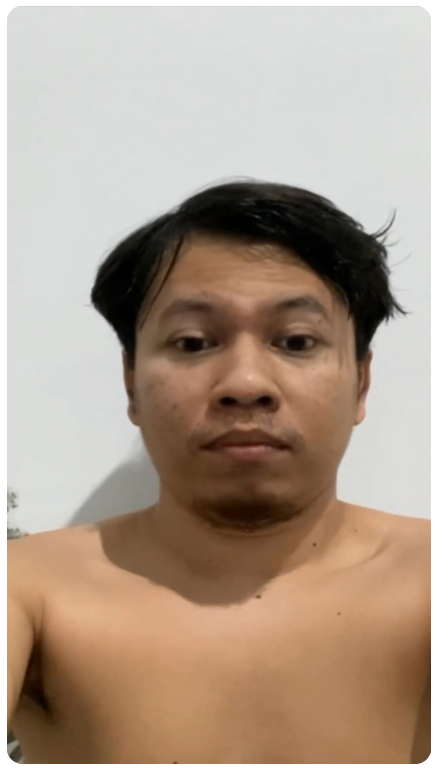

In [20]:
Image.open(list_images[3])

In [21]:
y_pred!=y_true

0      False
1      False
2      False
3      False
4       True
       ...  
145    False
146     True
147    False
148    False
149    False
Name: label, Length: 233, dtype: bool

DFD 1.2.0

In [22]:
res_0 = np.matmul([[0,0.3,0.3,0.4,0]],mat_feat[:,:,0])
res_1 = np.matmul([[0,0.3,0.3,0.4,0]],mat_feat[:,:,1])
roc_all = []
f1_all =[]
metrics_all = []
y_true = df_res_all["label"]
for i in range(len(res_0)): # Loop over all combinations
    logit = np.stack([res_0[i],res_1[i]],1)
    y_score = np.array([softmax_dim(i,-1)[1] for i in logit])
    y_pred = y_score>0.25
    metrics = evaluate_binary_classifier(y_true, y_pred, y_score)
    roc_all.append(metrics["ROC AUC"])
    f1_all.append(metrics["F1-Score"])
    metrics_all.append(metrics)
    #print(f"{mod_now}: {metrics}")

print(np.argwhere(f1_all == np.amax(f1_all)))
print(metrics_all[0])

[[0]]
{'Accuracy': 0.8626609442060086, 'Precision': 0.7580645161290323, 'Recall': 0.734375, 'F1-Score': 0.7460317460317459, 'Average Precision': 0.8646098359099392, 'FPR': 0.08875739644970414, 'FNR': 0.265625, 'ROC AUC': 0.9315828402366864, 'EER': 0.16877773668639054, 'EER Threshold': 0.09375488887863506}


In [47]:
prob_vectors_3=generate_prob_vectors([0,1,2,3], step=0.1)
res_0 = np.matmul(prob_vectors_3,mat_feat[1:,:,0])
res_1 = np.matmul(prob_vectors_3,mat_feat[1:,:,1])
roc_all = []
f1_all =[]
metrics_all = []
vec_all = []
thresh_all = []
ap_all = []
y_true = df_res_all["label"]
for i in range(len(res_0)): # Loop over all combinations
    vec_now = prob_vectors_3[i]
    logit = np.stack([res_0[i],res_1[i]],1)
    y_score = np.array([softmax(i)[1] for i in logit])
    for thresh_now in np.arange(0,0.4,0.025):
        y_pred = y_score>thresh_now
        metrics = evaluate_binary_classifier(y_true, y_pred, y_score)
        roc_all.append(metrics["ROC AUC"])
        f1_all.append(metrics["F1-Score"])
        ap_all.append(metrics["Average Precision"])
        metrics_all.append(metrics)
        vec_all.append(vec_now)
        thresh_all.append(thresh_now)
        #print(f"{mod_now}: {metrics}")

#print(np.argwhere(f1_all == np.amax(f1_all)))
#id_optimum =np.argwhere(f1_all == np.amax(f1_all))[0][0]
id_optimum = np.argwhere(ap_all == np.amax(ap_all))[0][0]
print(id_optimum)
print(metrics_all[id_optimum])
print(vec_all[id_optimum])
print(thresh_all[id_optimum])

4096
{'Accuracy': 0.27467811158798283, 'Precision': 0.27467811158798283, 'Recall': 1.0, 'F1-Score': 0.43097643097643096, 'Average Precision': 0.9107286117144588, 'FPR': 1.0, 'FNR': 0.0, 'ROC AUC': 0.9638498520710059, 'EER': 0.10498335798816569, 'EER Threshold': 0.011680779846886872}
[0.6, 0.1, 0.0, 0.3]
0.0


In [48]:
id_optimum = np.argwhere(ap_all == np.amax(ap_all))[1][0]
print(id_optimum)
print(metrics_all[id_optimum])
print(vec_all[id_optimum])
print(thresh_all[id_optimum])

4097
{'Accuracy': 0.9012875536480687, 'Precision': 0.8153846153846154, 'Recall': 0.828125, 'F1-Score': 0.8217054263565892, 'Average Precision': 0.9107286117144588, 'FPR': 0.07100591715976332, 'FNR': 0.171875, 'ROC AUC': 0.9638498520710059, 'EER': 0.10498335798816569, 'EER Threshold': 0.011680779846886872}
[0.6, 0.1, 0.0, 0.3]
0.025


In [24]:
vec_sorted= [vec_all[i] for i in np.argsort(roc_all)[::-1]]

In [25]:
vec_sorted

[[0.6, 0.0, 0.0, 0.4],
 [0.6, 0.0, 0.0, 0.4],
 [0.6, 0.0, 0.0, 0.4],
 [0.6, 0.0, 0.0, 0.4],
 [0.6, 0.0, 0.0, 0.4],
 [0.7, 0.0, 0.0, 0.3],
 [0.7, 0.0, 0.0, 0.3],
 [0.7, 0.0, 0.0, 0.3],
 [0.7, 0.0, 0.0, 0.3],
 [0.7, 0.0, 0.0, 0.3],
 [0.6, 0.1, 0.0, 0.3],
 [0.6, 0.1, 0.0, 0.3],
 [0.6, 0.1, 0.0, 0.3],
 [0.6, 0.1, 0.0, 0.3],
 [0.6, 0.1, 0.0, 0.3],
 [0.6, 0.0, 0.1, 0.3],
 [0.6, 0.0, 0.1, 0.3],
 [0.6, 0.0, 0.1, 0.3],
 [0.6, 0.0, 0.1, 0.3],
 [0.6, 0.0, 0.1, 0.3],
 [0.5, 0.1, 0.0, 0.4],
 [0.7, 0.1, 0.0, 0.2],
 [0.5, 0.1, 0.0, 0.4],
 [0.7, 0.1, 0.0, 0.2],
 [0.5, 0.1, 0.0, 0.4],
 [0.7, 0.1, 0.0, 0.2],
 [0.5, 0.1, 0.0, 0.4],
 [0.5, 0.1, 0.0, 0.4],
 [0.7, 0.1, 0.0, 0.2],
 [0.7, 0.1, 0.0, 0.2],
 [0.6, 0.1, 0.1, 0.2],
 [0.6, 0.1, 0.1, 0.2],
 [0.6, 0.1, 0.1, 0.2],
 [0.6, 0.1, 0.1, 0.2],
 [0.6, 0.1, 0.1, 0.2],
 [0.5, 0.1, 0.1, 0.3],
 [0.5, 0.1, 0.1, 0.3],
 [0.5, 0.1, 0.1, 0.3],
 [0.5, 0.1, 0.1, 0.3],
 [0.5, 0.1, 0.1, 0.3],
 [0.8, 0.0, 0.0, 0.2],
 [0.8, 0.0, 0.0, 0.2],
 [0.8, 0.0, 0.0, 0.2],
 [0.8, 0.0,

In [26]:
#check prob 2025/01/06 meeting

prob_vectors_3=[[0.6,0.0,0.1,0.3]]
res_0 = np.matmul(prob_vectors_3,mat_feat[1:,:,0])
res_1 = np.matmul(prob_vectors_3,mat_feat[1:,:,1])
roc_all = []
f1_all =[]
metrics_all = []
vec_all = []
thresh_all = []
y_true = df_res_all["label"]
for i in range(len(res_0)): # Loop over all combinations
    vec_now = prob_vectors_3[i]
    logit = np.stack([res_0[i],res_1[i]],1)
    y_score = np.array([softmax(i)[1] for i in logit])
    #for thresh_now in np.arange(0.2,0.7,0.1):
    for thresh_now in np.arange(0,0.3,0.05):
        y_pred = y_score>thresh_now
        metrics = evaluate_binary_classifier(y_true, y_pred, y_score)
        roc_all.append(metrics["ROC AUC"])
        f1_all.append(metrics["F1-Score"])
        metrics_all.append(metrics)
        vec_all.append(vec_now)
        thresh_all.append(thresh_now)
        #print(f"{mod_now}: {metrics}")

print(np.argwhere(f1_all == np.amax(f1_all)))
id_optimum =np.argwhere(f1_all == np.amax(f1_all))[0][0]
#print(np.argwhere(roc_all == np.amax(roc_all)))
#id_optimum =np.argwhere(roc_all == np.amax(roc_all))[1][0]
#id_optimum=0
print(metrics_all[id_optimum])
print(metrics_all[id_optimum]["ROC AUC"])
print(metrics_all[id_optimum]["FPR"])
print(metrics_all[id_optimum]["FNR"])
print(vec_all[id_optimum])
print(thresh_all[id_optimum])

[[2]]
{'Accuracy': 0.8755364806866953, 'Precision': 0.926829268292683, 'Recall': 0.59375, 'F1-Score': 0.7238095238095238, 'Average Precision': 0.9039217650800574, 'FPR': 0.01775147928994083, 'FNR': 0.40625, 'ROC AUC': 0.963387573964497, 'EER': 0.10012943786982248, 'EER Threshold': 0.009476786687732821}
0.963387573964497
0.01775147928994083
0.40625
[0.6, 0.0, 0.1, 0.3]
0.1


In [27]:
#check prob 2025/01/06 meeting

prob_vectors_3=[[0.6,0.1,0.0,0.3]]
res_0 = np.matmul(prob_vectors_3,mat_feat[1:,:,0])
res_1 = np.matmul(prob_vectors_3,mat_feat[1:,:,1])
roc_all = []
f1_all =[]
metrics_all = []
vec_all = []
thresh_all = []
y_true = df_res_all["label"]
for i in range(len(res_0)): # Loop over all combinations
    vec_now = prob_vectors_3[i]
    logit = np.stack([res_0[i],res_1[i]],1)
    y_score = np.array([softmax(i)[1] for i in logit])
    #for thresh_now in np.arange(0.2,0.7,0.1):
    for thresh_now in np.arange(0.02,0.3,0.1):
        y_pred = y_score>thresh_now
        metrics = evaluate_binary_classifier(y_true, y_pred, y_score)
        roc_all.append(metrics["ROC AUC"])
        f1_all.append(metrics["F1-Score"])
        metrics_all.append(metrics)
        vec_all.append(vec_now)
        thresh_all.append(thresh_now)
        #print(f"{mod_now}: {metrics}")

#print(np.argwhere(f1_all == np.amax(f1_all)))
#id_optimum =np.argwhere(f1_all == np.amax(f1_all))[0][0]
#print(np.argwhere(roc_all == np.amax(roc_all)))
#id_optimum =np.argwhere(roc_all == np.amax(roc_all))[1][0]
id_optimum=0
print(metrics_all[id_optimum])
print(metrics_all[id_optimum]["ROC AUC"])
print(metrics_all[id_optimum]["FPR"])
print(metrics_all[id_optimum]["FNR"])
print(vec_all[id_optimum])
print(thresh_all[id_optimum])

{'Accuracy': 0.9055793991416309, 'Precision': 0.8088235294117647, 'Recall': 0.859375, 'F1-Score': 0.8333333333333333, 'Average Precision': 0.9107286117144588, 'FPR': 0.07692307692307693, 'FNR': 0.140625, 'ROC AUC': 0.9638498520710059, 'EER': 0.10498335798816569, 'EER Threshold': 0.011680779846886872}
0.9638498520710059
0.07692307692307693
0.140625
[0.6, 0.1, 0.0, 0.3]
0.02


In [28]:
y_pred = y_score_100>0.75
list_images_100 = df_res_all[(y_pred!=y_true) & (df_res_all["label"]==1)]["image_name"].tolist()
y_pred = y_score>0.02
list_images_120 = df_res_all[(y_pred!=y_true) & (df_res_all["label"]==1)]["image_name"].tolist()
print(len(list_images_100))
print(len(list_images_120))
corrected_imgs = [i for i in list_images_100 if i not in list_images_120]
print(len(corrected_imgs))
wronged_imgs = [i for i in list_images_120 if i not in list_images_100]
print(len(wronged_imgs))

15
9
8
2


In [29]:
y_pred = y_score_100>0.75
list_images_100 = df_res_all[(y_pred!=y_true) & (df_res_all["label"]==0)]["image_name"].tolist()
y_pred = y_score>0.02
list_images_120 = df_res_all[(y_pred!=y_true) & (df_res_all["label"]==0)]["image_name"].tolist()
print(len(list_images_100))
print(len(list_images_120))
corrected_imgs = [i for i in list_images_100 if i not in list_images_120]
print(len(corrected_imgs))
wronged_imgs = [i for i in list_images_120 if i not in list_images_100]
print(len(wronged_imgs))

16
13
10
7


(<Figure size 1200x400 with 10 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

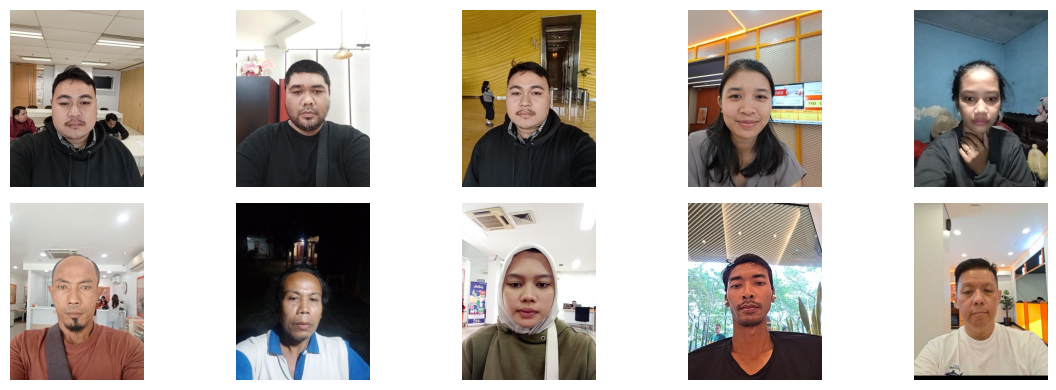

In [30]:
plot_multiple(corrected_imgs,nrow=2,figsize=(12,4))

(<Figure size 1200x400 with 8 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

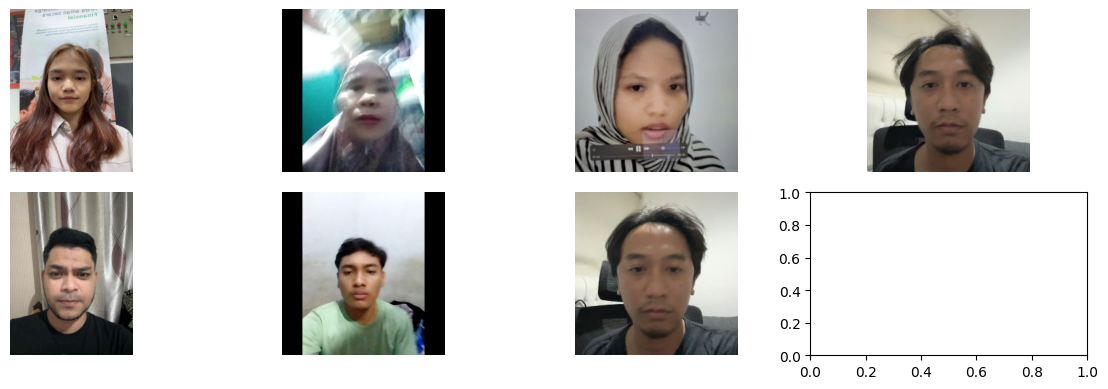

In [31]:
plot_multiple(wronged_imgs,nrow=2,figsize=(12,4))

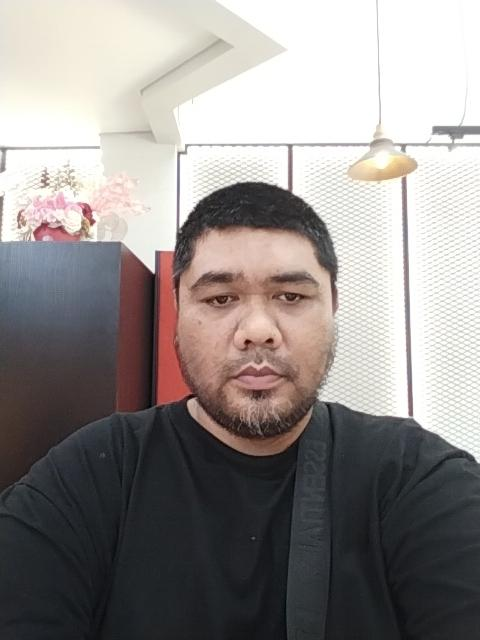

In [32]:
Image.open(corrected_imgs[2])

In [33]:
corrected_imgs = [i for i in list_images if i not in list_images_120]

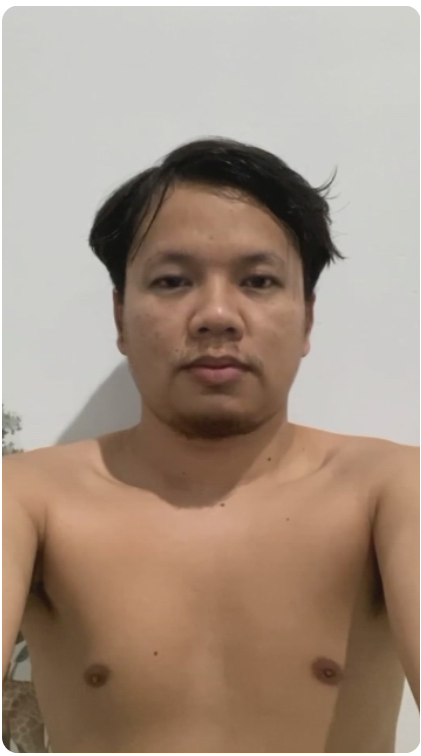

In [34]:
Image.open(corrected_imgs[2])

In [ ]:
prob_vectors_3=np.array(generate_prob_vectors([0,1,2,3], step=0.1))
res_scores = np.matmul(prob_vectors_3,mat_scores[1:,:])
roc_all = []
f1_all =[]
metrics_all = []
vec_all = []
thresh_all = []
y_true = df_res_all["label"]
for i in range(len(res_0)): # Loop over all combinations
    vec_now = prob_vectors_3[i]
    y_score = res_scores[i]
    for thresh_now in np.arange(0.2,0.7,0.1):
        y_pred = y_score>thresh_now
        metrics = evaluate_binary_classifier(y_true, y_pred, y_score)
        roc_all.append(metrics["ROC AUC"])
        f1_all.append(metrics["F1-Score"])
        metrics_all.append(metrics)
        vec_all.append(vec_now)
        thresh_all.append(thresh_now)
        #print(f"{mod_now}: {metrics}")

#print(np.argwhere(f1_all == np.amax(f1_all)))
#id_optimum =np.argwhere(f1_all == np.amax(f1_all))[0][0]
print(np.argwhere(roc_all == np.amax(roc_all)))
id_optimum =np.argwhere(roc_all == np.amax(roc_all))[1][0]
print(metrics_all[id_optimum])
print(vec_all[id_optimum])
print(thresh_all[id_optimum])

[[0]
 [1]
 [2]
 [3]
 [4]]
{'Accuracy': 0.8154506437768241, 'Precision': 0.8387096774193549, 'Recall': 0.40625, 'F1-Score': 0.5473684210526316, 'Average Precision': 0.7699463382758285, 'FPR': 0.029585798816568046, 'FNR': 0.59375, 'ROC AUC': 0.8953864644970414, 'EER': 0.16096523668639054, 'EER Threshold': 0.00692}
[0. 0. 0. 1.]
0.30000000000000004


In [36]:
mat_scores[0]

array([5.6819e-01, 9.9979e-01, 9.4302e-01, 9.9996e-01, 9.9993e-01,
       9.9953e-01, 9.9984e-01, 9.7643e-01, 9.9994e-01, 9.9961e-01,
       9.9961e-01, 9.9995e-01, 9.9997e-01, 9.9904e-01, 9.9998e-01,
       9.9996e-01, 9.9902e-01, 9.4374e-01, 9.9982e-01, 9.9958e-01,
       9.9997e-01, 9.9998e-01, 9.9982e-01, 9.7640e-01, 9.9986e-01,
       9.9983e-01, 9.9774e-01, 9.9312e-01, 9.9976e-01, 9.9961e-01,
       8.0714e-01, 9.9977e-01, 9.9991e-01, 9.9759e-01, 9.9894e-01,
       1.0000e+00, 9.9931e-01, 9.9974e-01, 9.9677e-01, 9.9931e-01,
       4.2118e-01, 1.0000e-05, 8.5097e-01, 9.9936e-01, 9.6444e-01,
       9.9963e-01, 1.0500e-03, 1.0000e-04, 2.9020e-02, 5.8980e-02,
       7.8087e-01, 8.5693e-01, 5.3600e-03, 6.2508e-01, 7.9320e-02,
       5.2519e-01, 8.3080e-02, 8.6318e-01, 4.7390e-02, 1.2050e-02,
       9.9958e-01, 9.0867e-01, 9.9720e-01, 9.9760e-01, 1.0000e+00,
       9.9948e-01, 9.9888e-01, 9.9988e-01, 9.9995e-01, 9.9923e-01,
       9.9946e-01, 6.8653e-01, 9.9816e-01, 9.9991e-01, 9.9307e

In [37]:
prob_vectors_3

array([[0. , 0. , 0. , 1. ],
       [0. , 0. , 0.1, 0.9],
       [0. , 0. , 0.2, 0.8],
       ...,
       [0.9, 0. , 0.1, 0. ],
       [0.9, 0.1, 0. , 0. ],
       [1. , 0. , 0. , 0. ]])

In [38]:
res_scores[10]

array([9.0176e-01, 8.2600e-03, 9.4896e-01, 3.7779e-01, 3.4200e-03,
       2.1400e-03, 9.1300e-03, 3.8909e-01, 6.9300e-03, 1.0991e-01,
       5.9900e-03, 2.5800e-03, 1.4053e-01, 4.3940e-02, 1.7390e-02,
       8.2307e-01, 1.1100e-03, 2.4304e-01, 4.2558e-01, 6.4540e-02,
       3.7810e-02, 5.0000e-04, 3.4970e-02, 3.1300e-03, 4.5200e-03,
       2.2080e-02, 9.4941e-01, 2.9570e-02, 8.7460e-02, 4.4000e-04,
       1.6340e-02, 1.8600e-03, 1.9710e-02, 6.9862e-01, 6.0520e-02,
       2.6900e-02, 1.7130e-01, 6.2960e-01, 6.2880e-01, 3.1790e-02,
       2.6240e-02, 1.0955e-01, 1.7600e-03, 6.1000e-03, 3.3929e-01,
       2.6100e-03, 1.7913e-01, 1.0417e-01, 7.4400e-03, 5.0861e-01,
       7.5970e-02, 9.9605e-01, 8.1850e-02, 1.0302e-01, 3.2500e-03,
       1.8000e-04, 5.0349e-01, 1.9100e-03, 5.5693e-01, 1.3913e-01,
       9.9992e-01, 8.8800e-03, 7.2738e-01, 2.9105e-01, 7.0310e-02,
       9.5659e-01, 8.2397e-01, 1.9486e-01, 9.6948e-01, 3.5015e-01,
       9.5752e-01, 8.0036e-01, 9.9448e-01, 2.6680e-02, 4.5010e

In [39]:
np.argsort(roc_all)

array([0, 1, 2, 3, 4])

In [41]:
prob_vectors_3=np.array([[0.6,0,0.1,0.3]])
res_scores = np.matmul(prob_vectors_3,mat_scores[1:,:])
roc_all = []
f1_all =[]
metrics_all = []
vec_all = []
thresh_all = []
y_true = df_res_all["label"]
for i in range(len(res_scores)): # Loop over all combinations
    vec_now = prob_vectors_3[i]
    y_score = res_scores[i]
    for thresh_now in np.arange(0.2,0.7,0.1):
        y_pred = y_score>thresh_now
        metrics = evaluate_binary_classifier(y_true, y_pred, y_score)
        roc_all.append(metrics["ROC AUC"])
        f1_all.append(metrics["F1-Score"])
        ap_all.append(metrics["Average Precision"])
        metrics_all.append(metrics)
        vec_all.append(vec_now)
        thresh_all.append(thresh_now)
        #print(f"{mod_now}: {metrics}")

#print(np.argwhere(f1_all == np.amax(f1_all)))
#id_optimum =np.argwhere(f1_all == np.amax(f1_all))[0][0]
id_optimum =np.argwhere(ap_all == np.amax(ap_all))[1][0]
print(id_optimum)
print(metrics_all[id_optimum])
print(metrics_all[id_optimum]["ROC AUC"])
print(metrics_all[id_optimum]["FPR"])
print(metrics_all[id_optimum]["FNR"])
print(vec_all[id_optimum])
print(thresh_all[id_optimum])

NameError: name 'ap_all' is not defined

In [76]:
#prob_vectors_3=np.array(generate_prob_vectors([0,1,2,3], step=0.1))
prob_vectors_3=np.array([[0.5,0,0.2,0.3]])
res_scores = np.matmul(prob_vectors_3,mat_scores[1:,:])
roc_all = []
f1_all =[]
metrics_all = []
vec_all = []
thresh_all = []
y_true = df_res_all["label"]
for i in range(len(res_scores)): # Loop over all combinations
    vec_now = prob_vectors_3[i]
    y_score = res_scores[i]
    #for thresh_now in np.arange(0.2,0.7,0.1):
    for thresh_now in np.arange(0.05,0.7,0.05):
        y_pred = y_score>thresh_now
        metrics = evaluate_binary_classifier(y_true, y_pred, y_score)
        roc_all.append(metrics["ROC AUC"])
        f1_all.append(metrics["F1-Score"])
        metrics_all.append(metrics)
        vec_all.append(vec_now)
        thresh_all.append(thresh_now)
        #print(f"{mod_now}: {metrics}")

#print(np.argwhere(f1_all == np.amax(f1_all)))
#id_optimum =np.argwhere(f1_all == np.amax(f1_all))[0][0]
print(np.argwhere(roc_all == np.amax(roc_all)))
id_optimum =np.argwhere(roc_all == np.amax(roc_all))[1][0]
print(metrics_all[id_optimum])
print(metrics_all[id_optimum]["ROC AUC"])
print(metrics_all[id_optimum]["FPR"])
print(metrics_all[id_optimum]["FNR"])
print(vec_all[id_optimum])
print(thresh_all[id_optimum])

[[ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]]
{'Accuracy': 0.8454935622317596, 'Precision': 0.7058823529411765, 'Recall': 0.75, 'F1-Score': 0.7272727272727272, 'Average Precision': 0.8686538900440124, 'FPR': 0.11834319526627218, 'FNR': 0.25, 'ROC AUC': 0.9405510355029586, 'EER': 0.1442769970414201, 'EER Threshold': 0.066916}
0.9405510355029586
0.11834319526627218
0.25
[0.5 0.  0.2 0.3]
0.1


In [56]:
prob_vectors_3.shape

(1, 5)

In [43]:
#merge by scores
prob_vectors_3=np.array(generate_prob_vectors([0,1,2,3], step=0.1))
res_scores = np.matmul(prob_vectors_3,mat_scores[1:,:])
roc_all = []
f1_all =[]
metrics_all = []
vec_all = []
thresh_all = []
ap_all = []
y_true = df_res_all["label"]
for i in range(len(prob_vectors_3)): # Loop over all combinations
    vec_now = prob_vectors_3[i]
    y_score = res_scores[i]
    for thresh_now in np.arange(0.2,0.7,0.1):
        y_pred = y_score>thresh_now
        metrics = evaluate_binary_classifier(y_true, y_pred, y_score)
        roc_all.append(metrics["ROC AUC"])
        f1_all.append(metrics["F1-Score"])
        ap_all.append(metrics["Average Precision"])
        metrics_all.append(metrics)
        vec_all.append(vec_now)
        thresh_all.append(thresh_now)
        #print(f"{mod_now}: {metrics}")

#print(np.argwhere(f1_all == np.amax(f1_all)))
#id_optimum =np.argwhere(f1_all == np.amax(f1_all))[0][0]
id_optimum = np.argwhere(ap_all == np.amax(ap_all))[1][0]
print(id_optimum)
print(metrics_all[id_optimum])
print(vec_all[id_optimum])
print(thresh_all[id_optimum])

1331
{'Accuracy': 0.8497854077253219, 'Precision': 0.9393939393939394, 'Recall': 0.484375, 'F1-Score': 0.6391752577319588, 'Average Precision': 0.8873391514555142, 'FPR': 0.011834319526627219, 'FNR': 0.515625, 'ROC AUC': 0.9516457100591715, 'EER': 0.1275887573964497, 'EER Threshold': 0.018335999999999998}
[0.7 0.  0.  0.3]
0.30000000000000004


In [67]:
print(len(res_scores))

286


In [65]:
mat_scores.shape

(5, 233)

In [46]:
list(df_res_all["image_name"])[-10:]

['/mnt/SSD/dataset/deepfake/data_client/processes/data_deepfake_raya/deepfake/face/450bea75-bd11-42e4-928e-2390cc3ff26a.jpg',
 '/mnt/SSD/dataset/deepfake/data_client/processes/data_deepfake_raya/deepfake/face/44617bc7-6f89-4992-879b-6fa071bb9318.jpg',
 '/mnt/SSD/dataset/deepfake/data_client/processes/data_deepfake_raya/deepfake/face/59d3e5c3-4787-467f-a9be-c57086c97f05.jpg',
 '/mnt/SSD/dataset/deepfake/data_client/processes/data_deepfake_raya/deepfake/face/7e264305-de80-4014-a006-c96620559c1f.jpg',
 '/mnt/SSD/dataset/deepfake/data_client/processes/data_deepfake_raya/deepfake/face/50b60adf-6ee0-4ea4-8ce3-5932436879b9.jpg',
 '/mnt/SSD/dataset/deepfake/data_client/processes/data_deepfake_raya/deepfake/face/7046e30e-f1fc-4297-be83-fe415cc90dc0.jpg',
 '/mnt/SSD/dataset/deepfake/data_client/processes/data_deepfake_raya/deepfake/face/fdeff956-f9c3-4818-95fb-63a18d277b04.jpg',
 '/mnt/SSD/dataset/deepfake/data_client/processes/data_deepfake_raya/deepfake/face/0bc33084-b099-444e-ba92-bde9739808a

In [30]:
prob_vectors_3.shape

(286, 4)

In [36]:
res_0 = np.matmul(prob_vectors_3,mat_scores[1:,:])


In [37]:
res_0.shape

(286, 233)

In [96]:
print(np.argwhere(roc_all == np.amax(roc_all)))
id_optimum =np.argwhere(roc_all == np.amax(roc_all))[2][0]
print(metrics_all[id_optimum])
print(vec_all[id_optimum])
print(thresh_all[id_optimum])

[[1255]
 [1256]
 [1257]
 [1258]
 [1259]]
{'Accuracy': 0.8369098712446352, 'Precision': 0.9642857142857143, 'Recall': 0.421875, 'F1-Score': 0.5869565217391304, 'Average Precision': 0.9072799058330011, 'FPR': 0.005917159763313609, 'FNR': 0.578125, 'ROC AUC': 0.9650517751479291, 'EER': 0.11385909763313609, 'EER Threshold': 0.006379725783423519}
[0.6, 0.0, 0.0, 0.4]
0.4000000000000001
